In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import minimum_filter
from scipy.ndimage import label, generate_binary_structure
import matplotlib.pyplot as plt
import matplotlib as mpl
import math

In [2]:
def distance(lon1, lat1, lon2, lat2):
        radius = 6371
        dlat = math.radians(lat2 - lat1)
        dlon = math.radians(lon2 - lon1)
        a = math.sin(dlat/2) * math.sin(dlat/2) + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2) * math.sin(dlon/2)
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
        d = radius * c
        return d


In [3]:
def crosses_dateline(labeled_arr, resolution):
    #Shift 180 degrees
    shifted_arr = np.roll(labeled_arr, 180*resolution, axis = 1)

    #Examine a 3x3 region centered at the dateline
    for lat in range(0, len(shifted_arr) - 1):
    	sample_arr = shifted_arr[lat:lat+2, 179:181]

    	top_left = sample_arr[0, 0]
    	top_right = sample_arr[0, 1]
    	bottom_right = sample_arr[1, 1]
    	bottom_left = sample_arr[1, 0]
		
    	#Compare top left with position next to it
    	if(top_left != 0 and top_right != 0):
    		if(top_left != top_right):
    			num_to_change = top_left
    			shifted_arr = np.where(shifted_arr != num_to_change, shifted_arr, top_right)
    			sample_arr = shifted_arr[lat:lat+2, 179:181]

    	#Compare top left with position diagonal to it
    	if(top_left != 0 and bottom_right != 0):
    		if(top_left != bottom_right):
    			num_to_change = top_left
    			shifted_arr = np.where(shifted_arr != num_to_change, shifted_arr, bottom_right)
    			sample_arr = shifted_arr[lat:lat+2, 179:181]
		
    	#Compate bottom left with position next to it
    	if(bottom_left != 0 and bottom_right != 0):
    		if(bottom_left != bottom_right):
    			num_to_change = bottom_left
    			shifted_arr = np.where(shifted_arr != num_to_change, shifted_arr, bottom_right)
    			sample_arr = shifted_arr[lat:lat+2, 179:181]
    			#print('Changed arr bot left, bot right', sample_arr)
    	
    	#Compare bottom left with position diagonal to it
    	if(bottom_left != 0 and top_right != 0):
    		if(bottom_left != top_right):
    			num_to_change = bottom_left
    			shifted_arr = np.where(shifted_arr != num_to_change, shifted_arr, top_right)
    			sample_arr = shifted_arr[lat:lat+2, 179:181]
    		
    return np.roll(shifted_arr, 180, axis = 1)
    
    

In [4]:
ds = xr.open_dataset('../notebooks/data/SLP_ex.nc')

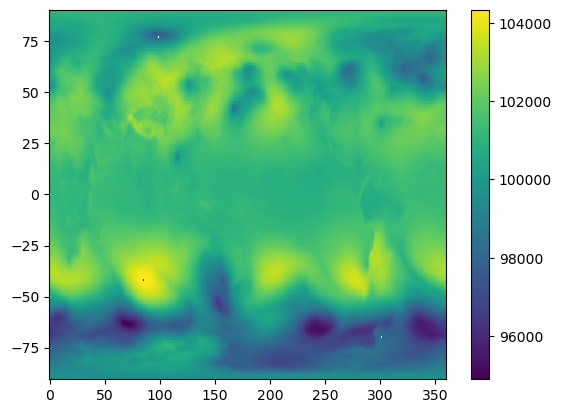

In [5]:
ds

#Just plot a sample time step of MSLP. Could also plot a loop
plt.pcolormesh(ds["longitude"].values, ds["latitude"].values, ds['SLP'].values[0])
plt.colorbar()

In [6]:
SLP = ds['SLP']

SLP_hPa = SLP / 100

In [7]:
SLP_arr = SLP_hPa.to_numpy()

In [ ]:
print(SLP_arr)

In [8]:
SLP_thresh = 1000 #Units of hPa

SLP_1000 = np.where(SLP_arr < SLP_thresh, SLP, 0)

In [ ]:
print(SLP_1000)

In [9]:
s = generate_binary_structure(2,2)

In [10]:
resolution = 1 #In degrees

labeled_arr = np.zeros_like(SLP_1000)

num_features_arr = np.zeros(len(SLP_1000))

for time_step in np.arange(0, len(SLP_1000)):
    labeled_SLP_field, num_features = label(SLP_1000[time_step], s)
  
    correct_labeled_SLP_field = crosses_dateline(labeled_SLP_field, resolution)
    
    num_features_arr[time_step] = num_features

    labeled_arr[time_step] = correct_labeled_SLP_field

    

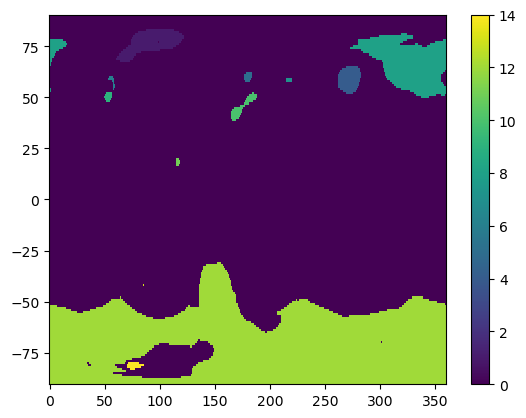

In [11]:
#Plot the labeled pfield. Could also plot a loop

plt.pcolormesh(ds["longitude"].values, ds["latitude"].values, labeled_arr[0])
plt.colorbar()

In [12]:
#Get SLP minimum for each identified object

In [13]:
minima = minimum_filter(SLP_arr, 5, mode=['nearest', 'wrap'], axes = [1, 2])
minima_3 = (SLP_arr == minima)
min_times, min_lats, min_lons = np.where(1 == minima_3)
print(min_times, min_lats, min_lons)

[ 0  0  0 ... 12 12 12] [  0   0   0 ... 180 180 180] [284 287 288 ...  61  62  63]


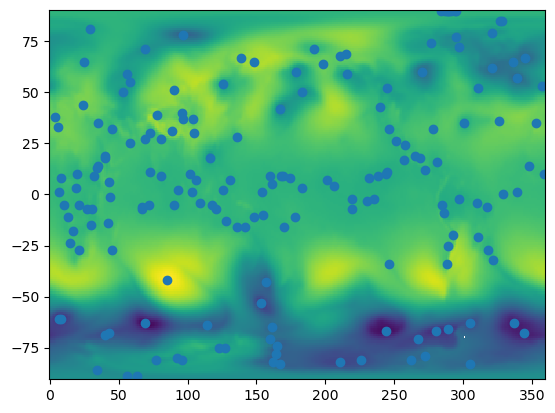

In [14]:
lons = ds["longitude"].values
lats = ds["latitude"].values

#Sample plot to show where the SLP minima are located
where_time = np.where(min_times == 0)

proper_time_lats = min_lats[where_time]
proper_time_lons = min_lons[where_time]

plt.pcolormesh(ds["longitude"].values, ds["latitude"].values, SLP_arr[0])
plt.scatter(lons[proper_time_lons], lats[proper_time_lats])



In [15]:
#Find the main SLP center for each object at each time step
deepest_mins_list = []

for time_step in np.arange(0, len(SLP_arr)):
    where_time = np.where(min_times == time_step)
    proper_time_lats = min_lats[where_time]
    proper_time_lons = min_lons[where_time]

    deepest_mins = {}
    print(labeled_arr[time_step].max())
    for label_num in range(1, int(labeled_arr[time_step].max() + 1)):

        mask = (labeled_arr[time_step, proper_time_lats, proper_time_lons] == label_num)

        if(not np.any(mask)):
            continue

        obj_lat = proper_time_lats[mask]
        obj_lon = proper_time_lons[mask]

        obj_slp = SLP_arr[time_step][obj_lat, obj_lon]

        lowest = np.argmin(obj_slp)

        deepest_mins[label_num] = (lats[obj_lat[lowest]], obj_lon[lowest])
    deepest_mins_list.append(deepest_mins)
    print(deepest_mins)
    

14.0
{1: (np.float32(78.0), np.int64(97)), 4: (np.float32(60.0), np.int64(270)), 5: (np.float32(60.0), np.int64(179)), 6: (np.float32(59.0), np.int64(56)), 7: (np.float32(59.0), np.int64(216)), 8: (np.float32(57.0), np.int64(339)), 9: (np.float32(50.0), np.int64(53)), 10: (np.float32(42.0), np.int64(167)), 11: (np.float32(18.0), np.int64(116)), 12: (np.float32(-63.0), np.int64(69)), 13: (np.float32(-42.0), np.int64(85)), 14: (np.float32(-81.0), np.int64(77))}
14.0
{1: (np.float32(78.0), np.int64(97)), 4: (np.float32(60.0), np.int64(271)), 5: (np.float32(60.0), np.int64(179)), 6: (np.float32(55.0), np.int64(58)), 7: (np.float32(59.0), np.int64(216)), 8: (np.float32(57.0), np.int64(339)), 9: (np.float32(50.0), np.int64(53)), 10: (np.float32(42.0), np.int64(168)), 11: (np.float32(19.0), np.int64(116)), 12: (np.float32(-64.0), np.int64(71)), 13: (np.float32(-75.0), np.int64(127)), 14: (np.float32(-80.0), np.int64(91))}
13.0
{1: (np.float32(78.0), np.int64(98)), 4: (np.float32(60.0), np.int

In [20]:
#We now have all minima at each time step. Now, it's time to stitch the tracks together
#Start with time step 1, check to see what's within 500 km. If none, then the track ends

first_time_step = deepest_mins_list[0]

for min_point in first_time_step:
    print('----------------------------')
    print('min_point')
    time_ind = 0
    
    #Start with minimum for first object
    min_point_lat = first_time_step[min_point][0]
    min_point_lon = first_time_step[min_point][1]

    still_exists = True

    while(still_exists):
        time_ind += 1

        if(time_ind > len(deepest_mins)):
            break
        
        #Go to next time step
        next_time_step = deepest_mins_list[time_ind]
        
        distances = np.zeros((len(next_time_step.items())))
        
        ind = 0
        for feat in next_time_step.values():
            dist = distance(min_point_lon, min_point_lat, feat[1], feat[0])
            distances[ind] = dist

            ind += 1
        
        min_dist = np.argmin(distances)
        #print(min_dist, next_time_step)
        if(min_dist < 500):
            new_min_point_lat = list(next_time_step.items())[min_dist][0]
            new_min_point_lon = list(next_time_step.items())[min_dist][1]
            print(new_min_point_lat, new_min_point_lon)
        else:
            print('System no longer exists')
            still_exists = False

    

----------------------------
min_point
1 (np.float32(78.0), np.int64(97))
1 (np.float32(78.0), np.int64(98))
1 (np.float32(79.0), np.int64(101))
1 (np.float32(79.0), np.int64(102))
1 (np.float32(79.0), np.int64(103))
1 (np.float32(79.0), np.int64(104))
1 (np.float32(79.0), np.int64(104))
1 (np.float32(79.0), np.int64(104))
----------------------------
min_point
4 (np.float32(60.0), np.int64(271))
4 (np.float32(60.0), np.int64(271))
4 (np.float32(60.0), np.int64(272))
4 (np.float32(60.0), np.int64(273))
4 (np.float32(60.0), np.int64(274))
4 (np.float32(60.0), np.int64(274))
4 (np.float32(61.0), np.int64(274))
4 (np.float32(61.0), np.int64(275))
----------------------------
min_point
5 (np.float32(60.0), np.int64(179))
5 (np.float32(60.0), np.int64(180))
5 (np.float32(60.0), np.int64(180))
5 (np.float32(60.0), np.int64(180))
5 (np.float32(52.0), np.int64(187))
5 (np.float32(52.0), np.int64(187))
5 (np.float32(60.0), np.int64(181))
5 (np.float32(53.0), np.int64(189))
---------------------

In [ ]:
#We now have all minima at each time step. Now, it's time to stitch the tracks together
#Start with time step 1, check to see what's within 500 km. If none, then the track ends

first_time_step = deepest_mins_list[0]

for min_point in first_time_step:
    time_ind = 0
    
    #Start with minimum for first object
    min_point_lat = first_time_step[min_point][0]
    min_point_lon = first_time_step[min_point][1]

    still_exists = True

    while(still_exists):
        print('here')
        time_ind += 1

        if(time_ind > len(deepest_mins)):
            break
        
        #Go to next time step
        next_time_step = deepest_mins_list[time_ind]
        print(next_time_step)
        distances = np.zeros((int(num_features_arr[time_ind])))
        
        ind = 0
        for feat in next_time_step.values():
            print(feat)
            dist = distance(min_point_lon, min_point_lat, feat[1], feat[0])
            distances[ind] = dist

            ind += 1

        min_dist = np.argmin(distances)
        print(min_dist, next_time_step)
        if(min_dist < 500):
            new_min_point_lat = list(next_time_step.items())[min_dist][0]
            new_min_point_lon = list(next_time_step.items())[min_dist][1]
        else:
            still_exists = False